<a href="https://colab.research.google.com/github/minhmax098/Brain-Tumor-CNN/blob/main/Brain_Tumor_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_dir = "/content/drive/MyDrive/Brain_Tumor_Project"
os.makedirs(project_dir, exist_ok=True)

print(project_dir)

/content/drive/MyDrive/Brain_Tumor_Project


In [ ]:
!pip install kagglehub -q

In [ ]:
import kagglehub

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Downloaded dataset path:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Downloaded dataset path: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
import os

path = "/kaggle/input/brain-tumor-mri-dataset"

print(os.listdir(path))
print(os.listdir(path + "/Training"))
print(os.listdir(path + "/Testing"))

['Training', 'Testing']
['pituitary', 'notumor', 'meningioma', 'glioma']
['pituitary', 'notumor', 'meningioma', 'glioma']


In [ ]:
import shutil
import os

source_dir = "/kaggle/input/brain-tumor-mri-dataset"
target_dir = "/content/drive/MyDrive/Brain_Tumor_Project/dataset"

if os.path.exists(target_dir):
    shutil.rmtree(target_dir)

shutil.copytree(source_dir, target_dir)

print("Copied dataset to:", target_dir)

Copied dataset to: /content/drive/MyDrive/Brain_Tumor_Project/dataset


In [ ]:
print(os.listdir("/content/drive/MyDrive/Brain_Tumor_Project/dataset"))
print(os.listdir("/content/drive/MyDrive/Brain_Tumor_Project/dataset/Training"))
print(os.listdir("/content/drive/MyDrive/Brain_Tumor_Project/dataset/Testing"))

['Testing', 'Training']
['pituitary', 'notumor', 'meningioma', 'glioma']
['pituitary', 'notumor', 'meningioma', 'glioma']


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Brain_Tumor_Project"
DATASET_DIR = os.path.join(PROJECT_DIR, "dataset")

TRAIN_DIR = os.path.join(DATASET_DIR, "Training")
TEST_DIR = os.path.join(DATASET_DIR, "Testing")

print("Train:", os.listdir(TRAIN_DIR))
print("Test:", os.listdir(TEST_DIR))

Train: ['pituitary', 'notumor', 'meningioma', 'glioma']
Test: ['pituitary', 'notumor', 'meningioma', 'glioma']


Import library

In [ ]:
!pip install opencv-python scikit-learn matplotlib seaborn tqdm -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

Check **GPU**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Device: cuda
Tesla T4


**CLAHE preprocessing**

In [ ]:
def apply_clahe_pil(img):
    img = np.array(img)

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    img = img.astype(np.uint8)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    img_clahe = clahe.apply(img)
    img_rgb = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)

    return Image.fromarray(img_rgb)

**DataLoader**

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Lambda(apply_clahe_pil),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Lambda(apply_clahe_pil),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Class to index:", train_dataset.class_to_idx)
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))
print("Number of classes:", num_classes)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class to index: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training samples: 5600
Testing samples: 1600
Number of classes: 4


**Dataset Distribution by Class**

            Train  Test
pituitary    1400   400
notumor      1400   400
meningioma   1400   400
glioma       1400   400


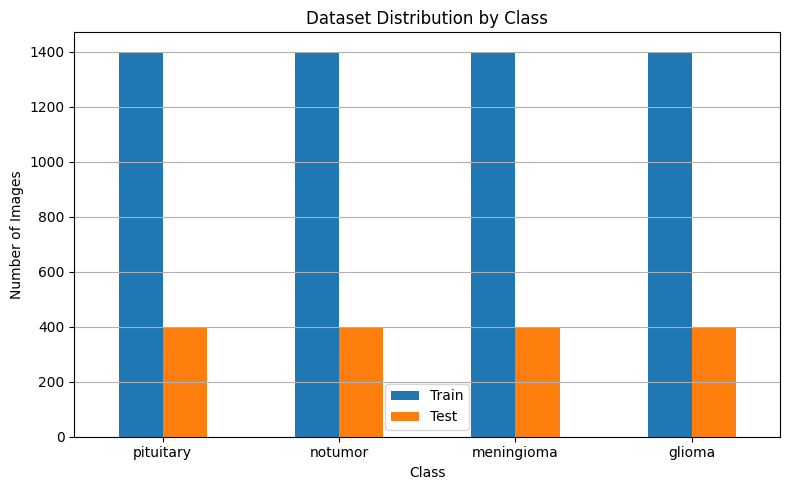

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def count_images(folder_path):
    counts = {}
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

df_counts = pd.DataFrame({
    "Train": train_counts,
    "Test": test_counts
}).fillna(0).astype(int)

print(df_counts)

df_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Dataset Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

**Sample MRI Images from Each Class**

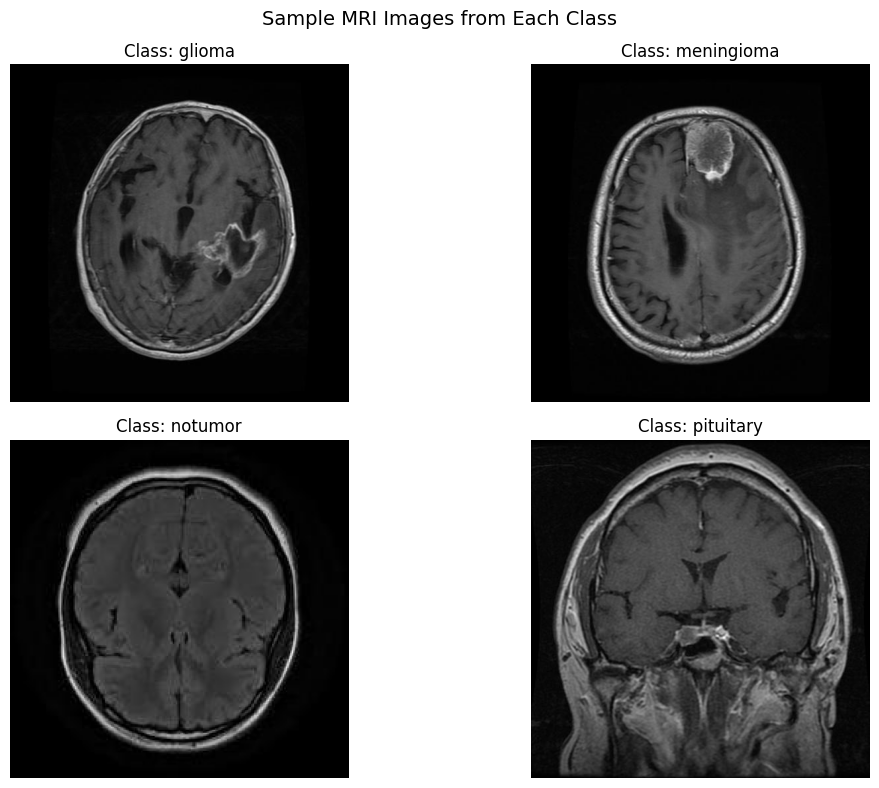

In [ ]:
import random
from PIL import Image

plt.figure(figsize=(12, 8))

idx = 1
for class_name in class_names:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    image_name = random.choice(os.listdir(class_dir))
    image_path = os.path.join(class_dir, image_name)

    img = Image.open(image_path).convert("RGB")

    plt.subplot(2, 2, idx)
    plt.imshow(img)
    plt.title(f"Class: {class_name}")
    plt.axis("off")

    idx += 1

plt.suptitle("Sample MRI Images from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

** Original MRI image and CLAHE-enhanced image**

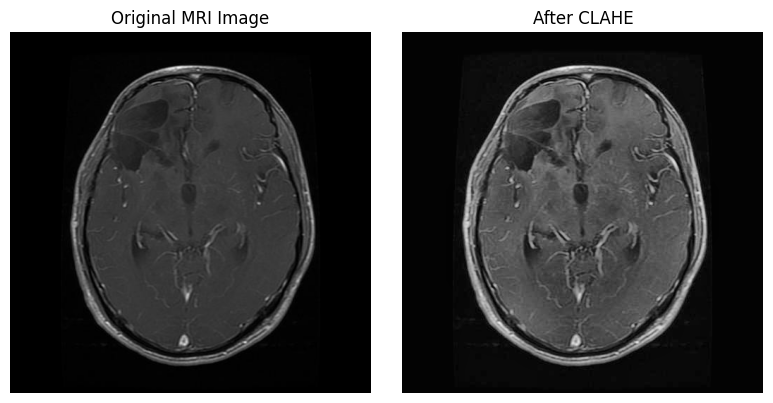

In [ ]:
sample_class = class_names[0]
sample_dir = os.path.join(TRAIN_DIR, sample_class)
sample_image = random.choice(os.listdir(sample_dir))
sample_path = os.path.join(sample_dir, sample_image)

original_img = Image.open(sample_path).convert("RGB")
clahe_img = apply_clahe_pil(original_img)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original MRI Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clahe_img)
plt.title("After CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

**Build model MobileNetV2**

In [ ]:
model = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
)

for param in model.features.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, num_classes)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.2,
    patience=2
)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 93.9MB/s]


In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, dataloader, criterion):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            total_loss += loss.item() * images.size(0)
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return total_loss / total, correct / total, np.array(all_labels), np.array(all_preds), np.array(all_probs)

**Train stage 1 (Transfer Learning)**

In [ ]:
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

EPOCHS_STAGE1 = 10

train_losses = []
test_losses = []
train_accs = []
test_accs = []

best_acc = 0

for epoch in range(EPOCHS_STAGE1):
    print(f"\nEpoch {epoch+1}/{EPOCHS_STAGE1}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer
    )

    test_loss, test_acc, y_true, y_pred, y_prob = evaluate(
        model, test_loader, criterion
    )

    scheduler.step(test_loss)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, "best_mobilenetv2_stage1.pth"))
        print("Saved best model.")


Epoch 1/10


100%|██████████| 50/50 [00:10<00:00,  5.00it/s]


Train Loss: 0.9032 | Train Acc: 0.6818
Test Loss: 0.6963 | Test Acc: 0.7675
Saved best model.

Epoch 2/10


100%|██████████| 50/50 [00:08<00:00,  5.57it/s]


Train Loss: 0.5587 | Train Acc: 0.8121
Test Loss: 0.6452 | Test Acc: 0.7688
Saved best model.

Epoch 3/10


...

Train Loss: 0.3938 | Train Acc: 0.8536
Test Loss: 0.5942 | Test Acc: 0.8000

Epoch 9/10


100%|██████████| 50/50 [00:09<00:00,  5.28it/s]


Train Loss: 0.3854 | Train Acc: 0.8570
Test Loss: 0.5902 | Test Acc: 0.8181
Saved best model.

Epoch 10/10


100%|██████████| 50/50 [00:10<00:00,  4.98it/s]

Train Loss: 0.3729 | Train Acc: 0.8652
Test Loss: 0.6135 | Test Acc: 0.8100


**Stage 2: Fine-tuning**

In [ ]:
# Unfreeze last layers of MobileNetV2 for fine-tuning
for param in model.features[-4:].parameters():
    param.requires_grad = True

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.2,
    patience=2
)

EPOCHS_STAGE2 = 30

best_val_loss = float("inf")
patience = 5
counter = 0

for epoch in range(EPOCHS_STAGE2):
    print(f"\nFine-tuning Epoch {epoch+1}/{EPOCHS_STAGE2}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer
    )

    test_loss, test_acc, y_true, y_pred, y_prob = evaluate(
        model, test_loader, criterion
    )

    scheduler.step(test_loss)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    # Save best model by accuracy
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(
            model.state_dict(),
            os.path.join(MODEL_DIR, "best_mobilenetv2_finetuned_acc.pth")
        )
        print("Saved best accuracy model.")

    # Early stopping by validation/test loss
    if test_loss < best_val_loss:
        best_val_loss = test_loss
        counter = 0
        torch.save(
            model.state_dict(),
            os.path.join(MODEL_DIR, "best_mobilenetv2_finetuned_loss.pth")
        )
        print("Saved best loss model.")
    else:
        counter += 1
        print(f"EarlyStopping Counter: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break


Fine-tuning Epoch 1/30


100%|██████████| 50/50 [00:10<00:00,  4.80it/s]


Train Loss: 0.3543 | Train Acc: 0.8709
Test Loss: 0.5538 | Test Acc: 0.8275
Saved best accuracy model.
Saved best loss model.

Fine-tuning Epoch 2/30


100%|██████████| 50/50 [00:10<00:00,  4.92it/s]


Train Loss: 0.3122 | Train Acc: 0.8873
Test Loss: 0.5228 | Test Acc: 0.8500
Saved best accuracy model.
Saved best loss model.

Fine-tuning Epoch 3/30


...

Train Loss: 0.1076 | Train Acc: 0.9629
Test Loss: 0.4530 | Test Acc: 0.9056
EarlyStopping Counter: 3/5

Fine-tuning Epoch 20/30


100%|██████████| 50/50 [00:10<00:00,  4.79it/s]


Train Loss: 0.1066 | Train Acc: 0.9613
Test Loss: 0.4282 | Test Acc: 0.9131
Saved best accuracy model.
EarlyStopping Counter: 4/5

Fine-tuning Epoch 21/30


100%|██████████| 50/50 [00:10<00:00,  4.83it/s]


Train Loss: 0.1036 | Train Acc: 0.9637
Test Loss: 0.4273 | Test Acc: 0.9137
Saved best accuracy model.
EarlyStopping Counter: 5/5
Early stopping triggered.


**Load the best model**

In [ ]:
BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_mobilenetv2_finetuned_acc.pth"
)

model.load_state_dict(
    torch.load(BEST_MODEL_PATH, map_location=device)
)

model.eval()

print("Best model loaded.")

Best model loaded.


**Final Evaluation**

In [ ]:
test_loss, test_acc, y_true, y_pred, y_prob = evaluate(
    model,
    test_loader,
    criterion
)

print(f" Final Test Accuracy: {test_acc:.4f}")

100%|██████████| 50/50 [00:10<00:00,  4.84it/s]

 Final Test Accuracy: 0.9137


**Classification report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.97      0.74      0.84       400
  meningioma       0.87      0.92      0.89       400
     notumor       0.87      1.00      0.93       400
   pituitary       0.96      0.99      0.98       400

    accuracy                           0.91      1600
   macro avg       0.92      0.91      0.91      1600
weighted avg       0.92      0.91      0.91      1600



In [ ]:
import os

OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output folder:", OUTPUT_DIR)

Output folder: /content/drive/MyDrive/Brain_Tumor_Project/outputs


**Confusion Matrix**

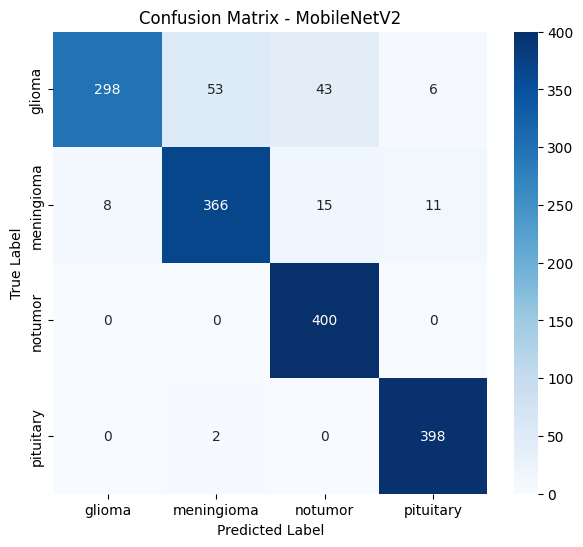

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/confusion_matrix.png


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - MobileNetV2")

save_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", save_path)

**ROC Curve + AUC**

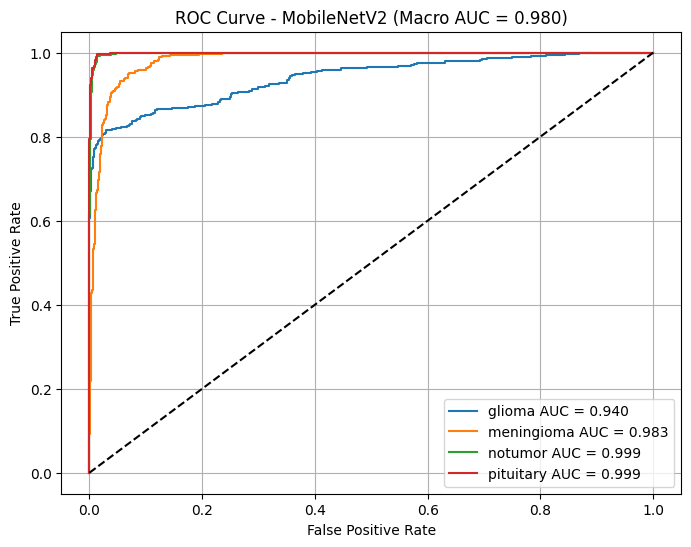

Macro AUC: 0.9802604166666667
Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/roc_curve_auc.png


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

y_true_bin = label_binarize(
    y_true,
    classes=list(range(num_classes))
)

plt.figure(figsize=(8, 6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} AUC = {roc_auc:.3f}"
    )

macro_auc = roc_auc_score(
    y_true_bin,
    y_prob,
    average="macro",
    multi_class="ovr"
)

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - MobileNetV2 (Macro AUC = {macro_auc:.3f})")
plt.legend()
plt.grid(True)

save_path = os.path.join(OUTPUT_DIR, "roc_curve_auc.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Macro AUC:", macro_auc)
print("Saved to:", save_path)

In [ ]:
train_losses
test_losses
train_accs
test_accs

[0.7675,
 0.76875,
 0.79625,
 0.795,
 0.79375,
 0.793125,
 0.80375,
 0.8,
 0.818125,
 0.81,
 0.8275,
 0.85,
 0.8475,
 0.865,
 0.86,
 0.866875,
 0.865,
 0.8725,
 0.873125,
 0.88125,
 0.885,
 0.89375,
 0.8925,
 0.899375,
 0.900625,
 0.91125,
 0.90375,
 0.9075,
 0.905625,
 0.913125,
 0.91375]

**Training and Validation Loss**

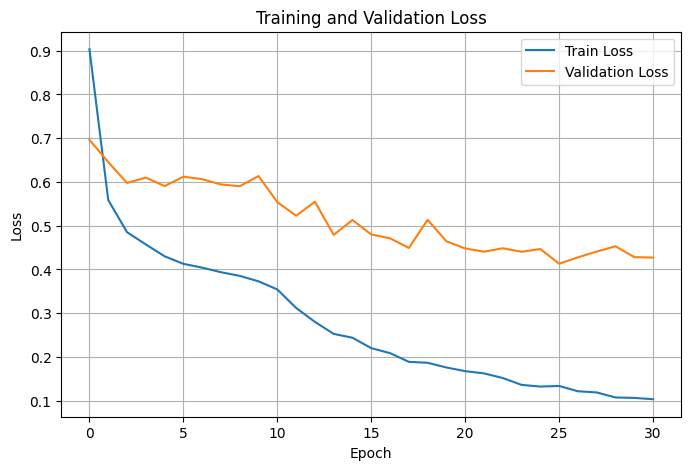

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/training_validation_loss.png


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

save_path = os.path.join(OUTPUT_DIR, "training_validation_loss.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", save_path)

**Training and Validation Accuracy**

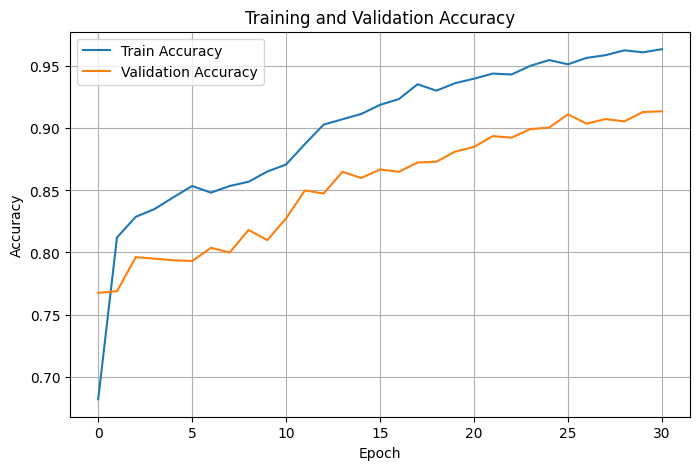

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/training_validation_accuracy.png


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

save_path = os.path.join(OUTPUT_DIR, "training_validation_accuracy.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", save_path)

**Create feature extractor**

In [ ]:
feature_extractor = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
)

feature_extractor.classifier = nn.Identity()

feature_extractor.features.load_state_dict(
    model.features.state_dict()
)

feature_extractor = feature_extractor.to(device)

feature_extractor.eval()

print("Feature extractor ready.")

Feature extractor ready.


**Extract deep features**

In [ ]:
def extract_features(model, dataloader):
    features = []
    labels_list = []

    model.eval()

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images = images.to(device)

            outputs = model(images)

            features.append(outputs.cpu().numpy())
            labels_list.extend(labels.numpy())

    features = np.concatenate(features, axis=0)
    labels_list = np.array(labels_list)

    return features, labels_list

**Extract train/test features**

In [ ]:
X_train, y_train = extract_features(
    feature_extractor,
    train_loader
)

X_test, y_test = extract_features(
    feature_extractor,
    test_loader
)

print("Train features:", X_train.shape)
print("Test features:", X_test.shape)

100%|██████████| 50/50 [00:11<00:00,  4.30it/s]

Train features: (5600, 1280)
Test features: (1600, 1280)


**PCA + SVM**

In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pca_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("svm", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

pca_svm.fit(X_train, y_train)

svm_pred = pca_svm.predict(X_test)
svm_prob = pca_svm.predict_proba(X_test)

print("PCA-SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

PCA-SVM Accuracy: 0.921875


**Classification Report PCA-SVM**

In [ ]:
print(classification_report(
    y_test,
    svm_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.99      0.76      0.86       400
  meningioma       0.86      0.94      0.90       400
     notumor       0.89      1.00      0.94       400
   pituitary       0.96      0.99      0.98       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600



In [ ]:
mobilenet_acc = accuracy_score(y_true, y_pred)

svm_acc = accuracy_score(y_test, svm_pred)

print("MobileNetV2 Accuracy:", mobilenet_acc)
print("PCA-SVM Accuracy:", svm_acc)

MobileNetV2 Accuracy: 0.91375
PCA-SVM Accuracy: 0.921875


**Build ResNet50 model**

In [ ]:
from torchvision import models
import torch.nn as nn
import torch.optim as optim
import os
import torch

resnet50 = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V1
)

# Freeze backbone first
for param in resnet50.parameters():
    param.requires_grad = False

in_features = resnet50.fc.in_features

resnet50.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)

resnet50 = resnet50.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_resnet = optim.Adam(
    resnet50.fc.parameters(),
    lr=1e-4
)

scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet,
    mode="min",
    factor=0.2,
    patience=2
)

print("ResNet50 model ready.")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 128MB/s]


ResNet50 model ready.


Stage 1 — Train ResNet50 classifier head

In [ ]:
EPOCHS_RESNET_STAGE1 = 10

resnet_train_losses = []
resnet_test_losses = []
resnet_train_accs = []
resnet_test_accs = []

best_resnet_acc = 0.0

for epoch in range(EPOCHS_RESNET_STAGE1):
    print(f"\nResNet50 Stage 1 Epoch {epoch+1}/{EPOCHS_RESNET_STAGE1}")

    train_loss, train_acc = train_one_epoch(
        resnet50,
        train_loader,
        criterion,
        optimizer_resnet
    )

    test_loss, test_acc, res_y_true, res_y_pred, res_y_prob = evaluate(
        resnet50,
        test_loader,
        criterion
    )

    scheduler_resnet.step(test_loss)

    resnet_train_losses.append(train_loss)
    resnet_test_losses.append(test_loss)
    resnet_train_accs.append(train_acc)
    resnet_test_accs.append(test_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    if test_acc > best_resnet_acc:
        best_resnet_acc = test_acc
        torch.save(
            resnet50.state_dict(),
            os.path.join(MODEL_DIR, "best_resnet50_stage1.pth")
        )
        print("Saved best ResNet50 stage1 model.")


ResNet50 Stage 1 Epoch 1/10


100%|██████████| 50/50 [00:09<00:00,  5.06it/s]


Train Loss: 0.8769 | Train Acc: 0.7048
Test Loss: 0.6352 | Test Acc: 0.7881
Saved best ResNet50 stage1 model.

ResNet50 Stage 1 Epoch 2/10


100%|██████████| 50/50 [00:10<00:00,  5.00it/s]


Train Loss: 0.5426 | Train Acc: 0.8187
Test Loss: 0.5775 | Test Acc: 0.7856

ResNet50 Stage 1 Epoch 3/10


...

Train Loss: 0.3827 | Train Acc: 0.8634
Test Loss: 0.5122 | Test Acc: 0.8125

ResNet50 Stage 1 Epoch 9/10


100%|██████████| 50/50 [00:10<00:00,  4.75it/s]


Train Loss: 0.3749 | Train Acc: 0.8662
Test Loss: 0.4832 | Test Acc: 0.8250
Saved best ResNet50 stage1 model.

ResNet50 Stage 1 Epoch 10/10


100%|██████████| 50/50 [00:09<00:00,  5.08it/s]

Train Loss: 0.3729 | Train Acc: 0.8680
Test Loss: 0.5008 | Test Acc: 0.8231


**Stage 2 — Fine-tune ResNet50**

In [ ]:
# Unfreeze layer4 for fine-tuning
for param in resnet50.layer4.parameters():
    param.requires_grad = True

optimizer_resnet = optim.Adam(
    filter(lambda p: p.requires_grad, resnet50.parameters()),
    lr=1e-5
)

scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet,
    mode="min",
    factor=0.2,
    patience=2
)

EPOCHS_RESNET_STAGE2 = 30

best_resnet_val_loss = float("inf")
patience = 5
counter = 0

for epoch in range(EPOCHS_RESNET_STAGE2):
    print(f"\nResNet50 Fine-tuning Epoch {epoch+1}/{EPOCHS_RESNET_STAGE2}")

    train_loss, train_acc = train_one_epoch(
        resnet50,
        train_loader,
        criterion,
        optimizer_resnet
    )

    test_loss, test_acc, res_y_true, res_y_pred, res_y_prob = evaluate(
        resnet50,
        test_loader,
        criterion
    )

    scheduler_resnet.step(test_loss)

    resnet_train_losses.append(train_loss)
    resnet_test_losses.append(test_loss)
    resnet_train_accs.append(train_acc)
    resnet_test_accs.append(test_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    if test_acc > best_resnet_acc:
        best_resnet_acc = test_acc
        torch.save(
            resnet50.state_dict(),
            os.path.join(MODEL_DIR, "best_resnet50_finetuned_acc.pth")
        )
        print("Saved best ResNet50 accuracy model.")

    if test_loss < best_resnet_val_loss:
        best_resnet_val_loss = test_loss
        counter = 0
        torch.save(
            resnet50.state_dict(),
            os.path.join(MODEL_DIR, "best_resnet50_finetuned_loss.pth")
        )
        print("Saved best ResNet50 loss model.")
    else:
        counter += 1
        print(f"EarlyStopping Counter: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break


ResNet50 Fine-tuning Epoch 1/30


100%|██████████| 50/50 [00:11<00:00,  4.46it/s]


Train Loss: 0.3142 | Train Acc: 0.8870
Test Loss: 0.4351 | Test Acc: 0.8600
Saved best ResNet50 accuracy model.
Saved best ResNet50 loss model.

ResNet50 Fine-tuning Epoch 2/30


100%|██████████| 50/50 [00:11<00:00,  4.46it/s]


Train Loss: 0.2177 | Train Acc: 0.9239
Test Loss: 0.3435 | Test Acc: 0.8956
Saved best ResNet50 accuracy model.
Saved best ResNet50 loss model.

ResNet50 Fine-tuning Epoch 3/30


...

Train Loss: 0.0360 | Train Acc: 0.9896
Test Loss: 0.3263 | Test Acc: 0.9456
Saved best ResNet50 accuracy model.
EarlyStopping Counter: 3/5

ResNet50 Fine-tuning Epoch 13/30


100%|██████████| 50/50 [00:10<00:00,  4.63it/s]


Train Loss: 0.0254 | Train Acc: 0.9930
Test Loss: 0.3706 | Test Acc: 0.9425
EarlyStopping Counter: 4/5

ResNet50 Fine-tuning Epoch 14/30


100%|██████████| 50/50 [00:10<00:00,  4.61it/s]

Train Loss: 0.0279 | Train Acc: 0.9921
Test Loss: 0.3539 | Test Acc: 0.9425
EarlyStopping Counter: 5/5
Early stopping triggered.


**Load best ResNet50 and evaluate**

In [ ]:
best_resnet_path = os.path.join(
    MODEL_DIR,
    "best_resnet50_finetuned_acc.pth"
)

resnet50.load_state_dict(
    torch.load(best_resnet_path, map_location=device)
)

resnet50.eval()

res_test_loss, res_test_acc, res_y_true, res_y_pred, res_y_prob = evaluate(
    resnet50,
    test_loader,
    criterion
)

print("Final ResNet50 Test Accuracy:", res_test_acc)

100%|██████████| 50/50 [00:10<00:00,  4.60it/s]

Final ResNet50 Test Accuracy: 0.945625


**Classification report for ResNet50**

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(
    res_y_true,
    res_y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       1.00      0.80      0.89       400
  meningioma       0.90      0.98      0.94       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.99      1.00      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.94      1600
weighted avg       0.95      0.95      0.94      1600



**Save ResNet50 confusion matrix**

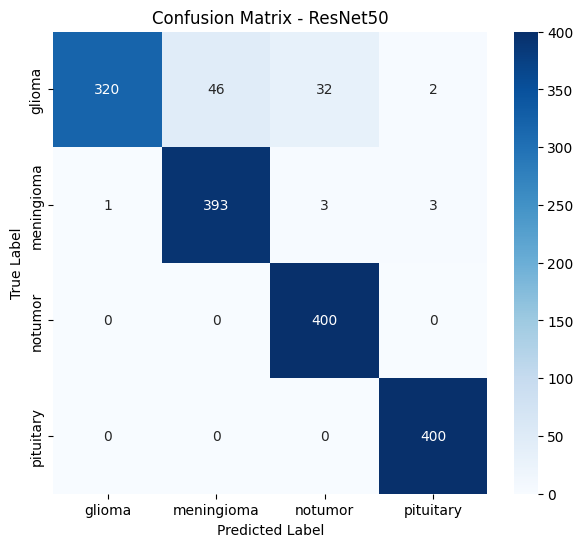

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/confusion_matrix_resnet50.png


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

res_cm = confusion_matrix(res_y_true, res_y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    res_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet50")

save_path = os.path.join(OUTPUT_DIR, "confusion_matrix_resnet50.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", save_path)

**Save ResNet50 training curves**

**Training and Validation Loss - ResNet50**

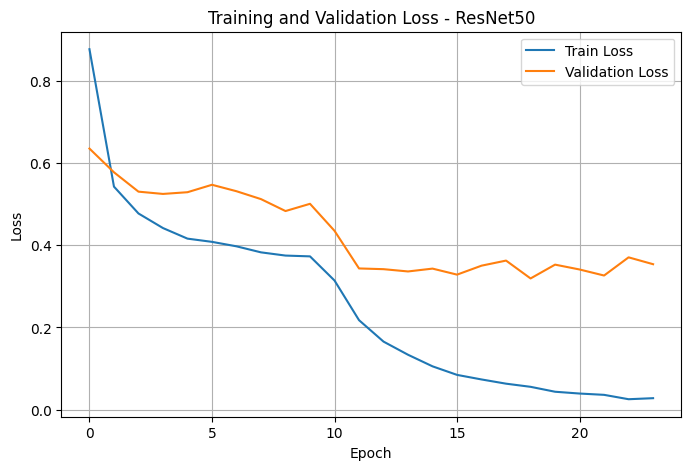

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/training_validation_loss_resnet50.png


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(resnet_train_losses, label="Train Loss")
plt.plot(resnet_test_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss - ResNet50")
plt.legend()
plt.grid(True)

save_path = os.path.join(OUTPUT_DIR, "training_validation_loss_resnet50.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", save_path)

**Training and Validation Accuracy - ResNet50**

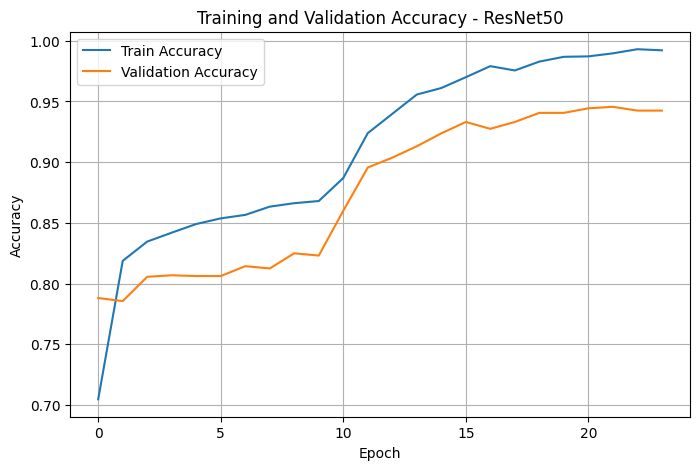

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/training_validation_accuracy_resnet50.png


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(resnet_train_accs, label="Train Accuracy")
plt.plot(resnet_test_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy - ResNet50")
plt.legend()
plt.grid(True)

save_path = os.path.join(OUTPUT_DIR, "training_validation_accuracy_resnet50.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", save_path)

**Compare MobileNetV2, PCA-SVM, ResNet50**

MobileNetV2 Accuracy: 0.91375
PCA-SVM Accuracy: 0.921875
ResNet50 Accuracy: 0.945625


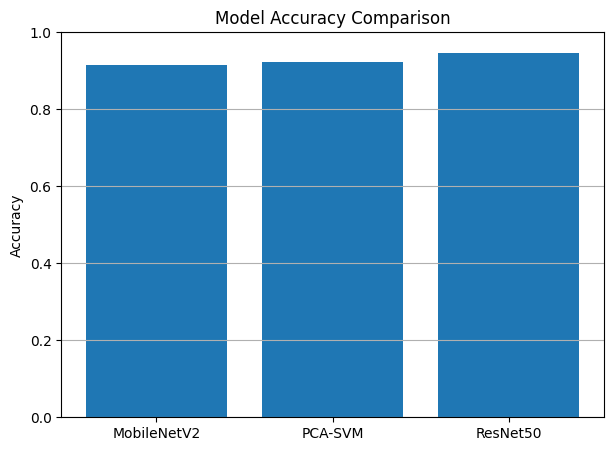

Saved to: /content/drive/MyDrive/Brain_Tumor_Project/outputs/model_accuracy_comparison.png


In [ ]:
mobilenet_acc = accuracy_score(y_true, y_pred)
svm_acc = accuracy_score(y_test, svm_pred)
resnet_acc = accuracy_score(res_y_true, res_y_pred)

print("MobileNetV2 Accuracy:", mobilenet_acc)
print("PCA-SVM Accuracy:", svm_acc)
print("ResNet50 Accuracy:", resnet_acc)

model_names = ["MobileNetV2", "PCA-SVM", "ResNet50"]
model_accs = [mobilenet_acc, svm_acc, resnet_acc]

plt.figure(figsize=(7, 5))
plt.bar(model_names, model_accs)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.grid(axis="y")

save_path = os.path.join(OUTPUT_DIR, "model_accuracy_comparison.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", save_path)

**Create ResNet50 Feature Extractor**

In [ ]:
resnet_feature_extractor = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V1
)

# Remove classifier
resnet_feature_extractor.fc = nn.Identity()

# Load trained weights
resnet_feature_extractor.load_state_dict(
    resnet50.state_dict(),
    strict=False
)

resnet_feature_extractor = resnet_feature_extractor.to(device)

resnet_feature_extractor.eval()

print("ResNet50 feature extractor ready.")

ResNet50 feature extractor ready.


**Extract Features**

In [ ]:
X_train_resnet, y_train_resnet = extract_features(
    resnet_feature_extractor,
    train_loader
)

X_test_resnet, y_test_resnet = extract_features(
    resnet_feature_extractor,
    test_loader
)

print("Train features:", X_train_resnet.shape)
print("Test features:", X_test_resnet.shape)

100%|██████████| 50/50 [00:11<00:00,  4.37it/s]

Train features: (5600, 2048)
Test features: (1600, 2048)


**PCA + SVM Resnet50**

In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

resnet_pca_svm = Pipeline([
    ("scaler", StandardScaler()),

    ("pca", PCA(
        n_components=0.95,
        random_state=42
    )),

    ("svm", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

resnet_pca_svm.fit(
    X_train_resnet,
    y_train_resnet
)

resnet_svm_pred = resnet_pca_svm.predict(X_test_resnet)

resnet_svm_prob = resnet_pca_svm.predict_proba(X_test_resnet)

**Accuracy**

In [ ]:
resnet_pca_svm_acc = accuracy_score(
    y_test_resnet,
    resnet_svm_pred
)

print("ResNet50 + PCA-SVM Accuracy:",
      resnet_pca_svm_acc)

ResNet50 + PCA-SVM Accuracy: 0.94375


**Classification Report**

In [ ]:
print(classification_report(
    y_test_resnet,
    resnet_svm_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       1.00      0.79      0.88       400
  meningioma       0.89      0.98      0.93       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.99      1.00      1.00       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600



**Final Comparison Table**

In [ ]:
mobilenet_acc = accuracy_score(y_true, y_pred)

svm_acc = accuracy_score(y_test, svm_pred)

resnet_acc = accuracy_score(
    res_y_true,
    res_y_pred
)

resnet_pca_svm_acc = accuracy_score(
    y_test_resnet,
    resnet_svm_pred
)

print("\nFINAL MODEL COMPARISON\n")

print("MobileNetV2:", mobilenet_acc)
print("MobileNetV2 + PCA-SVM:", svm_acc)
print("ResNet50:", resnet_acc)
print("ResNet50 + PCA-SVM:", resnet_pca_svm_acc)


FINAL MODEL COMPARISON

MobileNetV2: 0.91375
MobileNetV2 + PCA-SVM: 0.921875
ResNet50: 0.945625
ResNet50 + PCA-SVM: 0.94375
